In [1]:
import os

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, root_mean_squared_error

from Flame_fun import crop_flame_region, FL_fun

In [2]:
# Fonction de calcul de la longueur de flamme selon différentes méthodes

def FL_fun0(img_gray, methode='otsu', scale_pix2mm=20/230):
    """
    Input:
        img_gray (np.ndarray): Image en niveaux de gris
        methode (str): Méthode de seuillage ('otsu', '10', '15', 'fix')
        scale_pix2mm (float): Facteur de conversion pixel -> mm

    Output:
        flame_len_mm (float): Longueur de flamme estimée en mm
    """
    
    # L'idée générale : lisser l'image, segmenter la flamme,
    # nettoyer le masque, puis mesurer sa hauteur utile.
    gray_blur = cv2.GaussianBlur(img_gray, (5, 5), 0)

    # Seuillage selon la méthode choisie
    if methode == 'otsu':
        # Otsu : un seuil automatique + correction empiriquement
        otsu_val, _ = cv2.threshold(gray_blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        seuil_corrige = otsu_val * 0.44
        _, flame_mask = cv2.threshold(gray_blur, seuil_corrige, 255, cv2.THRESH_BINARY) 
               
    elif methode == '10':
        # Seuil relatif à 10 % de l'intensité max
        max_val = np.max(gray_blur)
        _, flame_mask = cv2.threshold(gray_blur, 0.10 * max_val, 255, cv2.THRESH_BINARY)
        
    elif methode == '15':
        # Seuil relatif à 15 % de l'intensité max
        max_val = np.max(gray_blur)
        _, flame_mask = cv2.threshold(gray_blur, 0.15 * max_val, 255, cv2.THRESH_BINARY)
        
    elif methode == 'fix':
        # Seuil fixe
        _, flame_mask = cv2.threshold(gray_blur, 13, 255, cv2.THRESH_BINARY)
        
    else:
        raise ValueError("Méthode non reconnue. Choisis 'otsu', '10' ou '15'.")

    # Nettoyage morphologique pour supprimer un peu de bruit
    kernel = np.ones((4, 4), np.uint8)
    mask_open = cv2.morphologyEx(flame_mask, cv2.MORPH_OPEN, kernel)
    mask_clean = cv2.morphologyEx(mask_open, cv2.MORPH_CLOSE, kernel)
    
    # Projection verticale : on repère les lignes où la flamme est présente
    Mask1D = np.sum(mask_clean, axis=1)
    flame_rows = np.where(Mask1D > 0)[0]
    
    if len(flame_rows) == 0:
        return 0.0 # 
        
    start_row = flame_rows[0]
    end_row = flame_rows[-1]
    
    flame_len_pix = end_row - start_row + 1
    flame_len_mm = flame_len_pix * scale_pix2mm
    
    return flame_len_mm

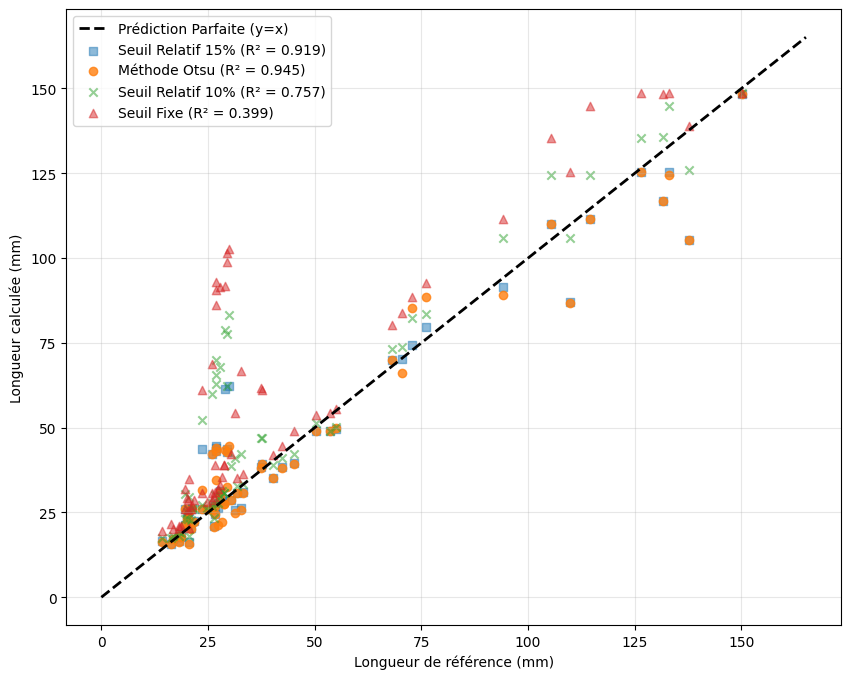

In [3]:
# Pour chaque méthode, comparaison des longueurs de flamme prédites aux valeurs de référence du dataset

def detective_longueur_flamme(csv_path, base_image_folder):
    """
    Input:
        csv_path (str): Chemin vers le fichier CSV contenant les données de référence
        base_image_folder (str): Dossier racine contenant les images

    Output:
        ind_outliers (np.ndarray): Indices des points considérés comme outliers
    """
    
    df = pd.read_csv(csv_path, sep=';')
    
    # On stocke les prédictions pour comparer plusieurs stratégies de seuillage
    valeurs_ref = []
    valeurs_otsu = []
    valeurs_seuil_10 = []
    valeurs_seuil_15 = []
    valeurs_seuil_fix = []
    err_abs = []
    
    
    for _, row in df.iterrows():
        
        # Extraction des paramètres géométriques et de la référence
        d1 = row.iloc[18]
        d2 = row.iloc[19]
        img_name = row.iloc[23]
        FL_ref = row.iloc[22]
        
        # Construction du chemin image (conversion en mm pour matcher l'arborescence)
        d1_mm = int(round(d1 * 1000))
        d2_mm = int(round(d2 * 1000))
        folder_name = f"d{d1_mm}D{d2_mm}"
        img_path = os.path.join(base_image_folder, folder_name, str(img_name))
        
        # Prétraitement : recadrage + niveaux de gris
        img_gray = crop_flame_region(img_path)
            
        # Calcul de la longueur de flamme selon différentes méthodes de seuillage
        L_otsu = FL_fun(img_gray)
        L_10 = FL_fun0(img_gray,'10')
        L_15 = FL_fun0(img_gray,'15')
        L_fix = FL_fun0(img_gray,'fix')
        
        # Stockage des résultats pour analyse globale
        valeurs_ref.append(FL_ref)
        valeurs_otsu.append(L_otsu)
        valeurs_seuil_10.append(L_10)
        valeurs_seuil_15.append(L_15)
        valeurs_seuil_fix.append(L_fix)
        err_abs.append(abs(FL_ref - L_otsu))


    r2_otsu = r2_score(valeurs_ref, valeurs_otsu)
    r2_10 = r2_score(valeurs_ref, valeurs_seuil_10)
    r2_15 = r2_score(valeurs_ref, valeurs_seuil_15)
    r2_fix = r2_score(valeurs_ref, valeurs_seuil_fix)

    # Seuil pour repérer les cas les outliers
    seuil_outliers = 1 * np.sqrt(np.mean(np.array(err_abs)**2))
    ind_outliers = np.where(err_abs > seuil_outliers)[0] 

    # Graphe de corrélation : référence vs prédiction
    plt.figure(figsize=(10, 8))
    
    max_val = max(valeurs_ref) * 1.1 if valeurs_ref else 100
    plt.plot([0, max_val], [0, max_val], 'k--', linewidth=2, label='Prédiction Parfaite (y=x)')
    
    plt.scatter(valeurs_ref, valeurs_seuil_15, alpha=0.5, label=f'Seuil Relatif 15% (R² = {r2_15:.3f})', marker='s')
    plt.scatter(valeurs_ref, valeurs_otsu, alpha=0.8, label=f'Méthode Otsu (R² = {r2_otsu:.3f})', marker='o')
    plt.scatter(valeurs_ref, valeurs_seuil_10, alpha=0.5, label=f'Seuil Relatif 10% (R² = {r2_10:.3f})', marker='x')
    plt.scatter(valeurs_ref, valeurs_seuil_fix, alpha=0.5, label=f'Seuil Fixe (R² = {r2_fix:.3f})', marker='^')
    
    plt.xlabel("Longueur de référence (mm)")
    plt.ylabel("Longueur calculée (mm)")
    plt.legend(loc='upper left') 
    plt.grid(True, alpha=0.3)
    plt.show()
    return ind_outliers

ind_outliers = detective_longueur_flamme("Data4FLpred.csv",".\data")


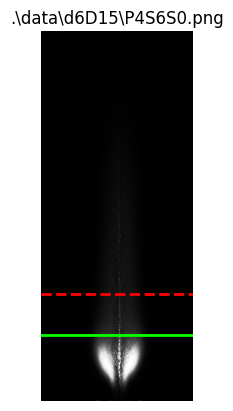

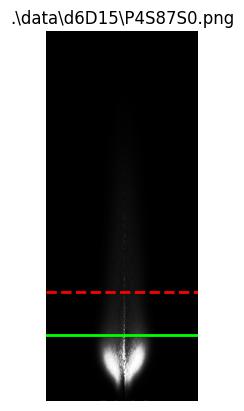

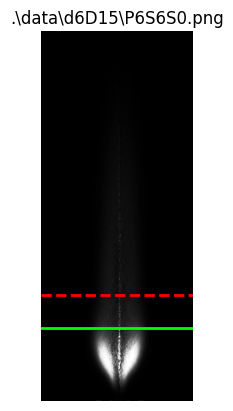

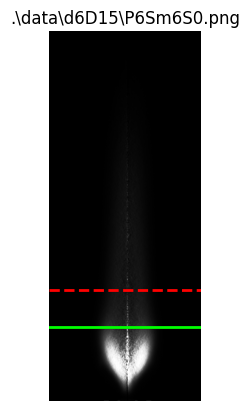

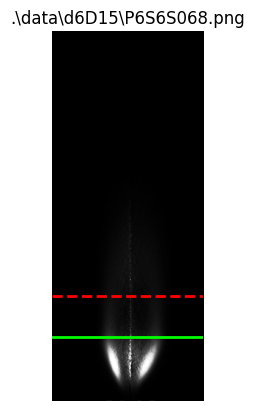

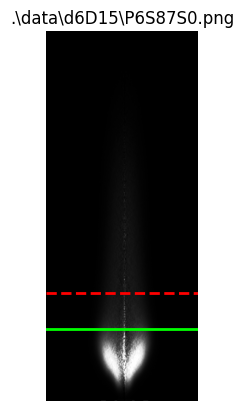

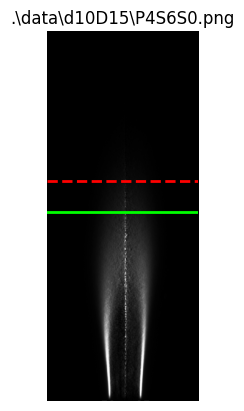

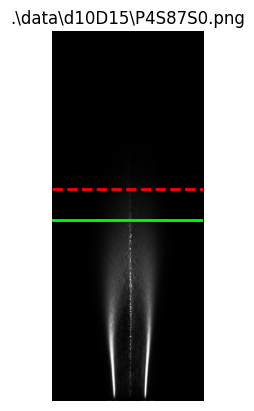

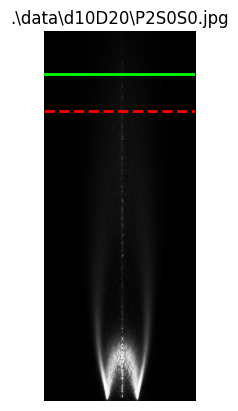

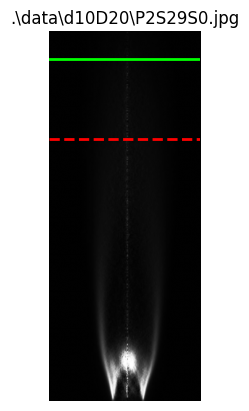

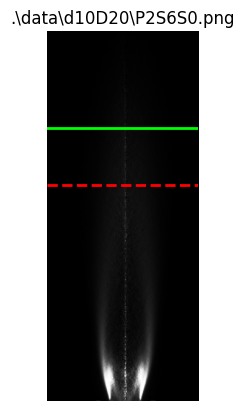

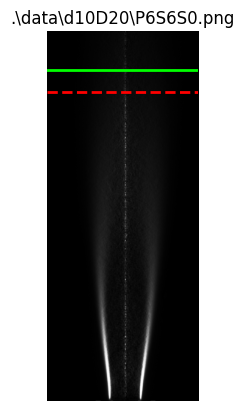

In [4]:
# Analyse visuelle des outliers :
# On affiche les images pour lesquelles la prédiction s'écarte le plus de la référence.

csv_path = "Data4FLpred.csv"
base_image_folder = r".\data"

# Réupération des outliers précédemment identifié
df = pd.read_csv(csv_path, sep=';')
df_outliers = df.iloc[ind_outliers].copy()

for _, row in df_outliers.iterrows():
        
        # Extraction des paramètres et de la valeur de référence
        d1 = row.iloc[18]
        d2 = row.iloc[19]
        img_name = row.iloc[23]
        FL_ref = row.iloc[22]
        
        # Reconstruction du chemin vers l'image
        d1_mm = int(round(d1 * 1000))
        d2_mm = int(round(d2 * 1000))
        folder_name = f"d{d1_mm}D{d2_mm}"
        img_path = os.path.join(base_image_folder, folder_name, str(img_name))
        
        # Prétraitement de l'image
        img_gray = crop_flame_region(img_path)
        
        # Prédiction de la longueur de flamme
        FL_pred = FL_fun0(img_gray)
        
        # Affichage avec superposition des longueurs (référence vs prédiction)
        plt.imshow(img_gray, cmap='gray')
        plt.axhline(y=1710 - FL_ref*230/20, color='lime', linestyle='-', linewidth=2, 
                label=f'Référence : {FL_ref:.1f} mm')   # Ligne verte : valeur de référence          
        plt.axhline(y=1710 - FL_pred*230/20, color='red', linestyle='--', linewidth=2, 
                label=f'Prédiction : {FL_pred:.1f} mm') # Ligne rouge : valeur prédite
        plt.title(f"{img_path}")
        plt.axis('off')
        plt.show()